PS0: Using GIS to Explore a Proposed NJYASA Structure
David Dunkerson

Section 1 — Background and Research Interest

Community youth football is generally organized through local programs that serve individual towns or communities. These organizations may participate in different leagues, and those leagues can have their own rules, registration processes, schedules, training requirements, and administrative systems. Unlike high school or college athletics, there is not one common statewide structure connecting all community youth football organizations in New Jersey.
TYASA is a youth sports organization I am developing with the broader goal of creating more structure, support, and consistency within community youth sports while allowing local organizations to remain independent. The idea is not for TYASA to take over individual youth programs. Instead, it would provide a larger system around them that could help create clearer processes, common standards, education and training resources, competition structures, and administrative support.
NJYASA is the proposed New Jersey state-level part of that larger TYASA model. My preliminary NJYASA concept divides New Jersey into three geographic regions—North, Central, and South. Each of New Jersey's 21 counties would serve as a county conference, and counties with larger numbers of participating organizations could be divided further into smaller geographic divisions. For example, Burlington County would be one conference within the proposed South Region.
My long-term goal for this GIS project is to determine whether this proposed structure makes geographic sense rather than relying only on the structure I originally created. I would eventually like to use the locations of youth football organizations, team participation, youth population, travel distance, and other geographic information to evaluate the proposed regions, conferences, and divisions. Burlington County is especially important because it is also the area where I plan to begin testing the TYASA model on a smaller scale.


Section 2 — Research Question, Unit of Analysis, and Data

Research Question:
How can the geographic distribution of community youth football organizations in New Jersey help evaluate and inform the proposed NJYASA regional and county-conference structure?

Unit of Analysis:
The initial unit of analysis will be New Jersey's 21 counties.

Geographic Scope:
The primary study area is the State of New Jersey. Burlington County will also serve as a more detailed area of focus because it is part of the proposed South Region and is the intended location for an early TYASA county-level pilot.

Data and Variables:
For the first stage of the project, I will use GIS boundary data for New Jersey's 21 counties. This will allow me to create a basic map of the proposed NJYASA regional structure. As the project develops, I plan to incorporate updated data on youth football organizations and their locations, the number of participating teams, youth population, population density, and travel distance. Additional community or demographic variables may also be considered if they help evaluate whether the proposed regions, conferences, and divisions are geographically practical.

Section 3 — GIS Data Source

For the initial map, I will use the County Boundaries of New Jersey dataset provided by the New Jersey Geographic Information Network (NJGIN) and the New Jersey Office of Information Technology, Office of GIS. This dataset contains the geographic boundaries for New Jersey's 21 counties and will provide the base geography for the proposed NJYASA regional and county-conference structure.

I selected this dataset because counties are the initial unit of analysis for the project, with each county representing a proposed NJYASA conference. The county boundaries will allow me to establish the statewide geographic framework before adding youth football organization locations and other variables later in the project.

Dataset: County Boundaries of NJ, Hosted, 3424

Source: New Jersey Geographic Information Network / NJ Office of Information Technology, Office of GIS

Data type: Polygon GIS data / hosted feature layer

Geographic coverage: State of New Jersey — 21 counties

Exact dataset source: https://www.arcgis.com/home/item.html?id=86d33b1f539843268de673825ebd47ec&utm=#overview

Section 4 — Load the GIS Data and Create the First Map

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = (
    "https://services2.arcgis.com/XVOqAjTOJ5P6ngMu/"
    "arcgis/rest/services/NJ_Counties_3424/FeatureServer/0/query"
    "?where=1%3D1&outFields=*&f=geojson"
)

In [3]:
nj_counties = gpd.read_file(url)

In [4]:
nj_counties.head()

,OBJECTID,COUNTY,COUNTY_LABEL,CO,GNIS_NAME,GNIS,FIPSSTCO,FIPSCO,ACRES,SQ_MILES,...,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,REGION,Shape__Area,Shape__Length,geometry
0,1,ATLANTIC,Atlantic County,ATL,County of Atlantic,882270,34001,1,390813.840968,610.646627,...,204615,450,450,414,451,335,COASTAL,1.702385e+10,650227.988137,"POLYGON ((-74.67437 39.68858, -74.67433 39.688..."
1,2,BERGEN,Bergen County,BER,County of Bergen,882271,34003,3,153491.054911,239.829773,...,849843,3985,3774,3686,3459,3544,NORTHEASTERN,6.686070e+09,443716.118141,"POLYGON ((-73.90569 40.98315, -73.90591 40.982..."
2,3,BURLINGTON,Burlington County,BUR,County of Burlington,882272,34005,5,524901.239967,820.158187,...,362542,563,547,516,482,442,SOUTHERN,2.286470e+10,788704.755123,"POLYGON ((-74.69864 40.18226, -74.69838 40.182..."
3,4,CAMDEN,Camden County,CAM,County of Camden,882273,34007,7,145594.972008,227.492144,...,471650,2301,2258,2237,2341,2073,SOUTHERN,6.342117e+09,495428.788831,"POLYGON ((-75.03314 39.99483, -75.03299 39.994..."
4,5,CAPE MAY,Cape May County,CAP,County of Cape May,882274,34009,9,183125.841721,286.134128,...,82266,333,340,358,332,288,COASTAL,7.976962e+09,514564.703916,"POLYGON ((-74.85962 39.31897, -74.85955 39.318..."


In [5]:
len(nj_counties)

21

<Axes: >

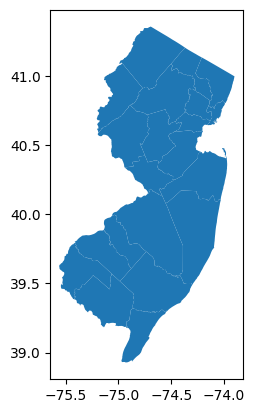

In [6]:
nj_counties.plot()

(np.float64(-75.64242383910356),
 np.float64(-73.81959467270454),
 np.float64(38.807065509412695),
 np.float64(41.47911153221721))

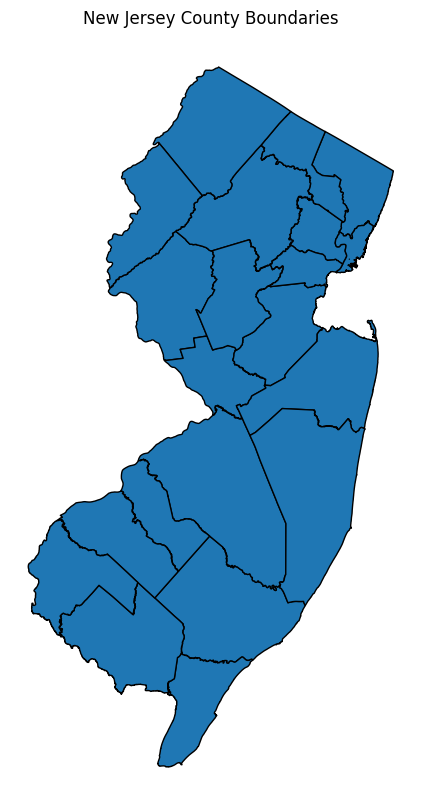

In [7]:
ax = nj_counties.plot(
    edgecolor="black",
    figsize=(8, 10)
)

ax.set_title("New Jersey County Boundaries")
ax.axis("off")

In [8]:
region_lookup = {
    "BERGEN": "North",
    "MORRIS": "North",
    "ESSEX": "North",
    "PASSAIC": "North",
    "SUSSEX": "North",
    "HUDSON": "North",
    "WARREN": "North",

    "MIDDLESEX": "Central",
    "UNION": "Central",
    "MONMOUTH": "Central",
    "SOMERSET": "Central",
    "OCEAN": "Central",
    "MERCER": "Central",
    "HUNTERDON": "Central",

    "CAMDEN": "South",
    "BURLINGTON": "South",
    "ATLANTIC": "South",
    "GLOUCESTER": "South",
    "CAPE MAY": "South",
    "CUMBERLAND": "South",
    "SALEM": "South"
}

In [9]:
nj_counties["NJYASA_REGION"] = nj_counties["COUNTY"].map(region_lookup)

In [10]:
nj_counties[["COUNTY", "NJYASA_REGION"]]

,COUNTY,NJYASA_REGION
0,ATLANTIC,South
1,BERGEN,North
2,BURLINGTON,South
3,CAMDEN,South
4,CAPE MAY,South
5,CUMBERLAND,South
6,ESSEX,North
7,GLOUCESTER,South
8,HUDSON,North
9,HUNTERDON,Central


In [11]:
nj_counties["NJYASA_REGION"].value_counts()

,count
NJYASA_REGION,
South,7
North,7
Central,7


<Axes: >

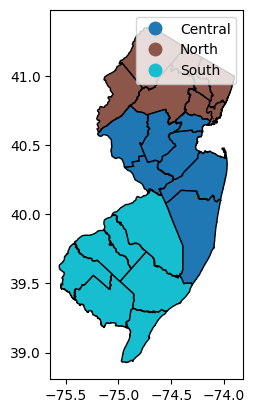

In [12]:
nj_counties.plot(
    column="NJYASA_REGION",
    categorical=True,
    legend=True,
    edgecolor="black"
)

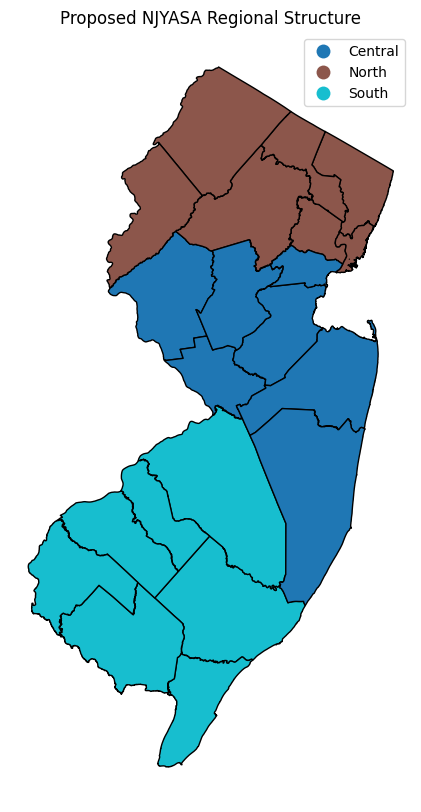

In [13]:
ax = nj_counties.plot(
    column="NJYASA_REGION",
    categorical=True,
    legend=True,
    edgecolor="black",
    figsize=(8, 10)
)

ax.set_title("Proposed NJYASA Regional Structure")
ax.axis("off");

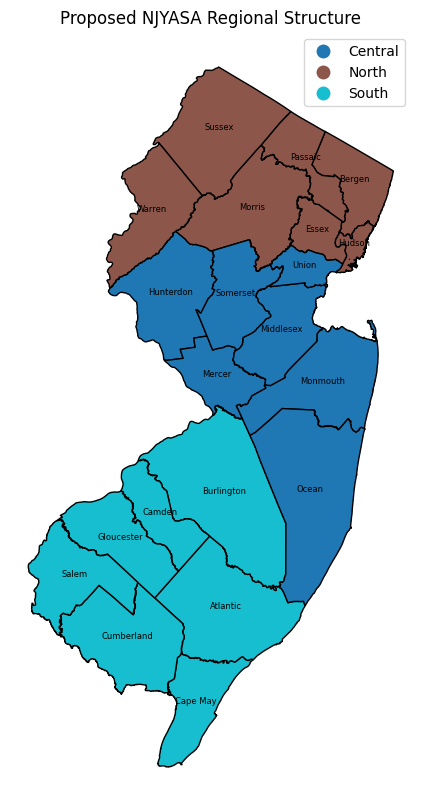

In [14]:
ax = nj_counties.plot(
    column="NJYASA_REGION",
    categorical=True,
    legend=True,
    edgecolor="black",
    figsize=(8, 10)
)

for idx, row in nj_counties.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(
        x,
        y,
        row["COUNTY"].title(),
        fontsize=6,
        ha="center"
    )

ax.set_title("Proposed NJYASA Regional Structure")
ax.axis("off");

Section 5 - Initial Map Interpretation

The map shows the preliminary three-region structure I developed for NJYASA. New Jersey's 21 counties are divided into proposed North, Central, and South regions, with seven counties in each region. Under the proposed structure, each county would function as a county conference, while larger conferences could eventually be divided into smaller geographic divisions.

Burlington County is included in the proposed South Region and will also serve as an initial area of focus for TYASA's county-level development. At this stage, the regional assignments represent a preliminary planning model rather than a final structure. Future analysis will use updated youth football organization locations, team distribution, youth population, and travel-related data to evaluate whether these regional boundaries are geographically practical or whether changes should be considered.

Portions of the Python code used in this notebook were developed with assistance from OpenAI ChatGPT and adapted to the NJYASA research project. The workflow also follows concepts demonstrated in the course materials.

# PS1: NJYASA Workforce Development

## Research Question

How does the geographic distribution of secondary-school students and undergraduate college students across New Jersey inform the potential for an NJYASA workforce-development system?

## Purpose

NJYASA is a proposed statewide youth sports system that would organize youth football into North, Central, and South Jersey leagues, with county-based conferences under each region. In addition to organizing competition, NJYASA could provide shared services and workforce-development opportunities for participating organizations.

One idea is to create opportunities for middle and high school students through programs such as junior officiating and other game-day roles. NJYASA could also partner with community colleges and universities to provide internships and experiential-learning opportunities in areas such as sports management, media, business, education, health, and data.

This analysis begins by examining where these two potential workforce populations are located across New Jersey.

In [15]:
len(nj_counties)

21

In [16]:
nj_counties.columns

Index(['OBJECTID', 'COUNTY', 'COUNTY_LABEL', 'CO', 'GNIS_NAME', 'GNIS',
       'FIPSSTCO', 'FIPSCO', 'ACRES', 'SQ_MILES', 'POP2020', 'POP2010',
       'POP2000', 'POP1990', 'POP1980', 'POPDEN2020', 'POPDEN2010',
       'POPDEN2000', 'POPDEN1990', 'POPDEN1980', 'REGION', 'Shape__Area',
       'Shape__Length', 'geometry', 'NJYASA_REGION'],
      dtype='object')

In [17]:
nj_counties[['COUNTY', 'COUNTY_LABEL', 'FIPSCO']].head()

,COUNTY,COUNTY_LABEL,FIPSCO
0,ATLANTIC,Atlantic County,1
1,BERGEN,Bergen County,3
2,BURLINGTON,Burlington County,5
3,CAMDEN,Camden County,7
4,CAPE MAY,Cape May County,9


In [18]:
njdoe_url = 'https://raw.githubusercontent.com/Dunk0725/GIS-26/main/Enrollment_2526.xlsx'

njdoe = pd.read_excel(
    njdoe_url,
    sheet_name='School',
    header=2
)

In [19]:
njdoe.head()

,County Code,County Name,District Code,District Name,School Code,School Name,Total Enrollment,White,%White,Black,...,Multilingual Learners,%Multilingual Learners,Migrant,%Migrant,Military,%Military,Homeless,%Homeless,Column1,Column2
0,01,Atlantic,10.0,Absecon Public Schools District,50.0,Emma C Attales,379.0,172.0,45.4,19.0,...,29.0,7.7,0.0,0.0,0.0,0.0,18.0,4.7,NaN,NaN
1,01,Atlantic,10.0,Absecon Public Schools District,60.0,H Ashton Marsh,518.0,226.0,43.6,25.0,...,66.0,12.7,0.0,0.0,0.0,0.0,26.0,5.0,NaN,NaN
2,01,Atlantic,110.0,Atlantic City School District,10.0,Atlantic City High School,1590.0,73.0,4.6,527.0,...,231.0,14.5,0.0,0.0,11.0,0.7,27.0,1.7,NaN,NaN
3,01,Atlantic,110.0,Atlantic City School District,300.0,Brighton Avenue School,314.0,6.0,1.9,29.0,...,155.0,49.4,0.0,0.0,1.0,0.3,0.0,0.0,NaN,NaN
4,01,Atlantic,110.0,Atlantic City School District,50.0,Chelsea Heights School,262.0,10.0,3.8,54.0,...,46.0,17.6,0.0,0.0,0.0,0.0,3.0,1.1,NaN,NaN


In [20]:
[c for c in njdoe.columns if 'Grade' in str(c)]

['First Grade',
 '%First Grade',
 'Second Grade',
 '%Second Grade',
 'Third Grade',
 '%Third Grade',
 'Fourth Grade',
 '%Fourth Grade',
 'Fifth Grade',
 '%Fifth Grade',
 'Sixth Grade',
 '%Sixth Grade',
 'Seventh Grade',
 '%Seventh Grade',
 'Eighth Grade',
 '%Eighth Grade',
 'Ninth Grade',
 '%Ninth Grade',
 'Tenth Grade',
 '%Tenth Grade',
 'Eleventh Grade',
 '%Eleventh Grade',
 'Twelfth Grade',
 '%Twelfth Grade']

In [21]:
grade_cols = [
    'Sixth Grade',
    'Seventh Grade',
    'Eighth Grade',
    'Ninth Grade',
    'Tenth Grade',
    'Eleventh Grade',
    'Twelfth Grade'
]

njdoe['Grades_6_12'] = njdoe[grade_cols].sum(axis=1)

In [22]:
njdoe[['County Name', 'School Name', 'Grades_6_12']].head()

,County Name,School Name,Grades_6_12
0,Atlantic,Emma C Attales,297.0
1,Atlantic,H Ashton Marsh,1.0
2,Atlantic,Atlantic City High School,1590.0
3,Atlantic,Brighton Avenue School,1.0
4,Atlantic,Chelsea Heights School,107.0


In [23]:
sorted(njdoe['County Name'].dropna().unique())

['Atlantic',
 'Bergen',
 'Burlington',
 'Camden',
 'Cape May',
 'Charters',
 'Cumberland',
 'Essex',
 'Gloucester',
 'Hudson',
 'Hunterdon',
 'Mercer',
 'Middlesex',
 'Monmouth',
 'Morris',
 'Ocean',
 'Passaic',
 'Salem',
 'Somerset',
 'Sussex',
 'Union',
 'Warren']

In [24]:
njdoe_counties = (
    njdoe[njdoe['County Name'] != 'Charters']
    .groupby('County Name', as_index=False)['Grades_6_12']
    .sum()
)

In [25]:
njdoe_counties

,County Name,Grades_6_12
0,Atlantic,21666.0
1,Bergen,70317.5
2,Burlington,35802.0
3,Camden,39796.0
4,Cape May,5920.0
5,Cumberland,14142.0
6,Essex,63113.0
7,Gloucester,24173.5
8,Hudson,39300.0
9,Hunterdon,9202.0


In [26]:
njdoe_counties['COUNTY'] = njdoe_counties['County Name'].str.upper()

In [27]:
njdoe_counties.head()

,County Name,Grades_6_12,COUNTY
0,Atlantic,21666.0,ATLANTIC
1,Bergen,70317.5,BERGEN
2,Burlington,35802.0,BURLINGTON
3,Camden,39796.0,CAMDEN
4,Cape May,5920.0,CAPE MAY


In [28]:
len(njdoe_counties)

21

In [29]:
join1_check = nj_counties.merge(
    njdoe_counties,
    on='COUNTY',
    how='outer',
    indicator=True
)

In [30]:
join1_check['_merge'].value_counts()

,count
_merge,
both,21
left_only,0
right_only,0


In [31]:
nj_ps1 = join1_check.drop(columns='_merge')

In [32]:
nj_ps1[['COUNTY', 'Grades_6_12']].head()

,COUNTY,Grades_6_12
0,ATLANTIC,21666.0
1,BERGEN,70317.5
2,BURLINGTON,35802.0
3,CAMDEN,39796.0
4,CAPE MAY,5920.0


## Map 1: Potential Secondary-School Workforce

This map shows 2025–2026 public-school enrollment in grades 6 through 12 by New Jersey county. These students represent a potential population for future NJYASA career-development opportunities such as junior officiating and other youth sports workforce roles.

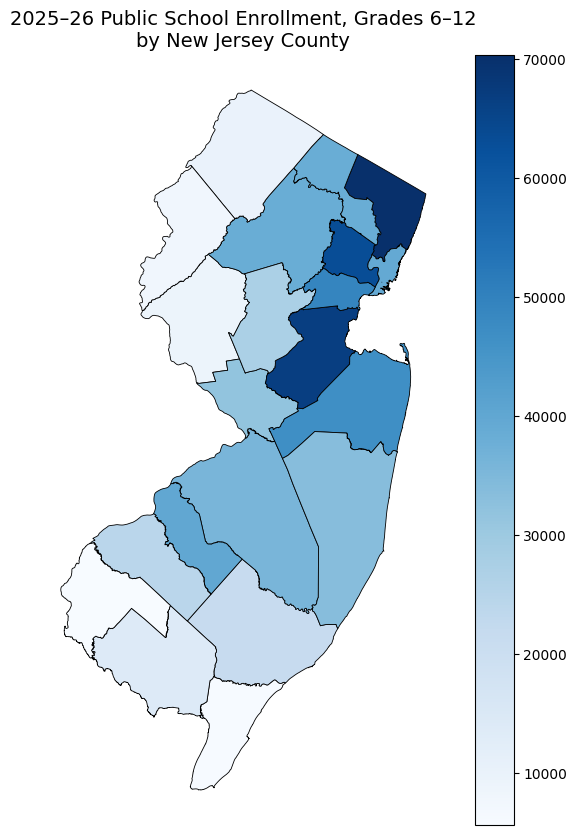

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

nj_ps1.plot(
    column='Grades_6_12',
    cmap='Blues',
    edgecolor='black',
    linewidth=0.6,
    legend=True,
    ax=ax
)

ax.set_title(
    '2025–26 Public School Enrollment, Grades 6–12\nby New Jersey County',
    fontsize=14
)

ax.axis('off')

plt.show()

### Interpretation

The map shows that grades 6–12 public-school enrollment is not evenly distributed across New Jersey counties. Counties such as Bergen, Middlesex, and Essex have some of the largest secondary-school student populations, while counties such as Cape May, Salem, and Warren have much smaller populations.

For NJYASA, this suggests that the potential pool for programs such as junior officiating and other youth sports workforce opportunities may vary substantially by county. Counties with smaller student populations may need to rely more heavily on regional partnerships rather than building every workforce program independently.

## Variable 2: Undergraduate Enrollment

The second variable examines Fall 2024 undergraduate enrollment at degree-granting colleges and universities located in New Jersey. This represents a potential pool of college students who could participate in NJYASA internships and experiential-learning opportunities.

In [34]:
hd_url = 'https://raw.githubusercontent.com/Dunk0725/GIS-26/main/hd2024.csv'
enrollment_url = 'https://raw.githubusercontent.com/Dunk0725/GIS-26/main/drvef2024.csv'

hd = pd.read_csv(hd_url)
enrollment = pd.read_csv(enrollment_url)

In [35]:
hd.head()

,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,...,CBSA,CBSATYPE,CSA,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG
0,100654,Alabama A & M University,AAMU,4900 Meridian Street,Normal,AL,35762,1,5,Dr. Daniel K. Wims,...,26620,1,290,1089,Madison County,105,-86.568502,34.783368,106,1
1,100663,University of Alabama at Birmingham,UAB,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,...,13820,1,142,1073,Jefferson County,107,-86.799345,33.505697,91,1
2,100690,Amridge University,Southern Christian University Regions University,1200 Taylor Rd,Montgomery,AL,36117-3553,1,5,Michael C.Turner,...,33860,1,388,1101,Montgomery County,102,-86.174010,32.362609,125,2
3,100706,University of Alabama in Huntsville,UAH University of Alabama Huntsville,301 Sparkman Dr,Huntsville,AL,35899,1,5,Chuck Karr,...,26620,1,290,1089,Madison County,105,-86.640449,34.724557,91,2
4,100724,Alabama State University,NaN,915 S Jackson Street,Montgomery,AL,36104-0271,1,5,Quinton T. Ross,...,33860,1,388,1101,Montgomery County,102,-86.295677,32.364317,97,1


In [36]:
enrollment.head()

,UNITID,ENRTOT,FTE,ENRFT,ENRPT,PCTENRWH,PCTENRBK,PCTENRHS,PCTENRAP,PCTENRAS,...,RMUNKNWP,PCTDEEXC,PCTDESOM,PCTDENON,PCUDEEXC,PCUDESOM,PCUDENON,PCGDEEXC,PCGDESOM,PCGDENON
0,100654,7295,6683,6291,1004,2,87,2,0,0,...,1.0,4,66,29,4.0,69.0,27.0,7.0,43.0,50.0
1,100663,20905,17030,14679,6226,48,22,7,8,8,...,0.0,28,41,31,19.0,58.0,22.0,39.0,19.0,42.0
2,100690,639,410,266,373,36,56,3,1,1,...,NaN,100,0,0,100.0,0.0,0.0,100.0,0.0,0.0
3,100706,8564,7157,6286,2278,67,10,7,4,4,...,0.0,11,50,39,6.0,60.0,34.0,27.0,14.0,58.0
4,100724,4081,3803,3627,454,4,85,1,0,0,...,0.0,13,75,11,7.0,81.0,12.0,54.0,39.0,7.0


In [37]:
hd[['UNITID', 'INSTNM', 'STABBR', 'COUNTYNM', 'DEGGRANT']].head()

,UNITID,INSTNM,STABBR,COUNTYNM,DEGGRANT
0,100654,Alabama A & M University,AL,Madison County,1
1,100663,University of Alabama at Birmingham,AL,Jefferson County,1
2,100690,Amridge University,AL,Montgomery County,1
3,100706,University of Alabama in Huntsville,AL,Madison County,1
4,100724,Alabama State University,AL,Montgomery County,1


In [38]:
[c for c in enrollment.columns if 'UG' in str(c)]

['EFUG',
 'EFUG1ST',
 'EFUGTRN',
 'EFUGCNT',
 'EFUGNDG',
 'EFUGFT',
 'EFUG1SFT',
 'EFUGTRFT',
 'EFUGCNFT',
 'EFUGNDFT',
 'EFUGPT',
 'EFUG1SPT',
 'EFUGTRPT',
 'EFUGCNPT',
 'EFUGNDPT']

In [39]:
nj_colleges = hd[
    (hd['STABBR'] == 'NJ') &
    (hd['DEGGRANT'] == 1)
].copy()

In [40]:
nj_colleges[['UNITID', 'INSTNM', 'COUNTYNM']].head()

,UNITID,INSTNM,COUNTYNM
1889,183488,Eastwick College-Hackensack,Bergen County
1890,183600,Assumption College for Sisters,Morris County
1891,183655,Atlantic Cape Community College,Atlantic County
1893,183743,Bergen Community College,Bergen County
1894,183789,Berkeley College-Woodland Park,Passaic County


In [41]:
nj_colleges_enrollment = nj_colleges.merge(
    enrollment[['UNITID', 'EFUG']],
    on='UNITID',
    how='left'
)

In [42]:
nj_colleges_enrollment[['INSTNM', 'COUNTYNM', 'EFUG']].head()

,INSTNM,COUNTYNM,EFUG
0,Eastwick College-Hackensack,Bergen County,1171
1,Assumption College for Sisters,Morris County,30
2,Atlantic Cape Community College,Atlantic County,4052
3,Bergen Community College,Bergen County,11720
4,Berkeley College-Woodland Park,Passaic County,1907


In [43]:
nj_colleges_enrollment['EFUG'].isna().sum()

np.int64(0)

In [44]:
college_counties = (
    nj_colleges_enrollment
    .groupby('COUNTYNM', as_index=False)['EFUG']
    .sum()
)

In [45]:
college_counties

,COUNTYNM,EFUG
0,Atlantic County,11617
1,Bergen County,31576
2,Burlington County,6620
3,Camden County,11479
4,Cumberland County,2686
5,Essex County,34953
6,Gloucester County,21318
7,Hudson County,18628
8,Mercer County,29562
9,Middlesex County,52607


In [46]:
college_counties['COUNTY'] = (
    college_counties['COUNTYNM']
    .str.replace(' County', '', regex=False)
    .str.upper()
)

In [47]:
college_counties.head()

,COUNTYNM,EFUG,COUNTY
0,Atlantic County,11617,ATLANTIC
1,Bergen County,31576,BERGEN
2,Burlington County,6620,BURLINGTON
3,Camden County,11479,CAMDEN
4,Cumberland County,2686,CUMBERLAND


In [48]:
join2_check = nj_ps1.merge(
    college_counties[['COUNTY', 'EFUG']],
    on='COUNTY',
    how='outer',
    indicator=True
)

In [49]:
join2_check['_merge'].value_counts()

,count
_merge,
both,19
left_only,2
right_only,0


In [50]:
join2_check[join2_check['_merge'] != 'both'][['COUNTY', '_merge']]

,COUNTY,_merge
4,CAPE MAY,left_only
9,HUNTERDON,left_only


In [51]:
nj_ps1 = join2_check.drop(columns='_merge')

nj_ps1['EFUG'] = nj_ps1['EFUG'].fillna(0)

In [52]:
nj_ps1[['COUNTY', 'EFUG']].sort_values('EFUG').head()

,COUNTY,EFUG
4,CAPE MAY,0.0
9,HUNTERDON,0.0
16,SALEM,1135.0
20,WARREN,1880.0
18,SUSSEX,2247.0


## Map 2: Potential College Internship Workforce

This map shows Fall 2024 undergraduate enrollment at degree-granting colleges and universities located in each New Jersey county. These students represent a potential pool for NJYASA internships and experiential-learning opportunities in areas such as sports management, media, business, education, health, and data.

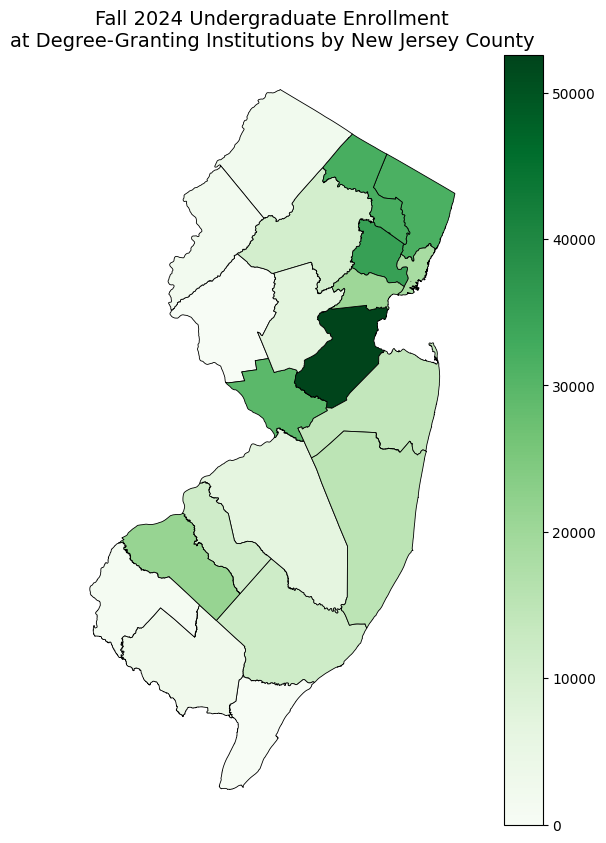

In [53]:
fig, ax = plt.subplots(figsize=(8, 10))

nj_ps1.plot(
    column='EFUG',
    cmap='Greens',
    edgecolor='black',
    linewidth=0.6,
    legend=True,
    ax=ax
)

ax.set_title(
    'Fall 2024 Undergraduate Enrollment\nat Degree-Granting Institutions by New Jersey County',
    fontsize=14
)

ax.axis('off')

plt.show()

### Interpretation

Undergraduate enrollment at degree-granting institutions is also unevenly distributed across New Jersey. Middlesex County has the largest undergraduate enrollment in this dataset, while counties such as Essex, Bergen, Passaic, and Mercer also have relatively large college-student populations. Cape May and Hunterdon Counties have no degree-granting institutions represented in the IPEDS data and therefore have an undergraduate enrollment value of zero in this analysis.

For NJYASA, this suggests that the ability to develop college internship and experiential-learning partnerships may vary by county. Counties with large college populations may have more opportunities to develop local partnerships, while counties with fewer or no degree-granting institutions may need to work with colleges in neighboring counties or through the broader North, Central, or South Jersey league structure.

## Comparison and NJYASA Application

The two maps show that New Jersey's potential secondary-school workforce and college internship workforce are not distributed in exactly the same way. Some counties, including Middlesex, Bergen, Essex, Passaic, and Mercer, have relatively large populations in both datasets. These areas may provide strong opportunities for NJYASA to develop both youth workforce programs and partnerships with colleges and universities.

Other counties show a different pattern. For example, Burlington County has a substantial grades 6–12 population but a much smaller undergraduate population at degree-granting institutions located within the county. Cape May and Hunterdon Counties have secondary-school populations but no undergraduate enrollment from degree-granting institutions located within the county in this dataset.

This difference supports the idea of organizing NJYASA through both county conferences and larger regional leagues. County conferences could coordinate local organizations and youth workforce programs, while the North, Central, and South Jersey leagues could help connect counties with colleges, universities, and other workforce-development partners located elsewhere in the region.

The results suggest that NJYASA should not expect every county to have the same workforce resources. A regional structure could allow resources and partnerships to be shared across county boundaries while local organizations continue to serve their individual communities.

## Limitations and Future Research

This analysis is an early step in evaluating the workforce-development potential of the proposed NJYASA structure. The grades 6–12 enrollment data represent public-school students and exclude charter-school enrollment because NJDOE reports charter schools separately from the 21 geographic counties. The undergraduate enrollment data measure students attending degree-granting institutions located within each county, not necessarily students who live in that county.

The maps also do not show actual interest in youth sports careers, internship availability, employment eligibility, or the number of existing youth football organizations in each county.

Future analysis will add the locations of youth football organizations, their league affiliations, home fields, school and service-area relationships, and potential county and regional partners. This will allow NJYASA to examine where workforce-development programs such as junior officiating, media internships, sports management, and other MENC-related opportunities could be most effectively connected to existing youth sports organizations.

## Data Sources

**New Jersey County Boundaries**  
New Jersey Office of Information Technology / NJGIN. County Boundaries of New Jersey.  
https://services2.arcgis.com/XVOqAjTOJ5P6ngMu/arcgis/rest/services/NJ_Counties_3424/FeatureServer/0

**New Jersey Public School Enrollment**  
New Jersey Department of Education. 2025–2026 Fall Enrollment Reports.  
https://www.nj.gov/education/doedata/enr/

The 2025–2026 enrollment workbook used in this analysis is also stored in the project GitHub repository so the notebook can load the same file directly.

**College and University Enrollment**  
U.S. Department of Education, National Center for Education Statistics, Integrated Postsecondary Education Data System (IPEDS). 2024 Directory Information and Fall Enrollment data.  
https://nces.ed.gov/ipeds/datacenter/DataFiles.aspx

The HD2024 and DRVEF2024 files used in this analysis are also stored in the project GitHub repository so the notebook can load the same files directly.

## AI Use Disclosure

ChatGPT was used to assist with developing the research question, organizing the notebook, explaining GIS and Python concepts, troubleshooting code, and drafting Python code used to clean, join, analyze, and map the data. I reviewed, ran, and interpreted the code and results throughout the analysis.